In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("E:/Project/Submissions/Datasets/Final_Data.csv")
df

,day,energy_median,energy_mean,energy_max,energy_std,energy_sum,energy_min,time,temperatureMax,windBearing,...,cloudy,fog,partly-cloudy-day,partly-cloudy-night,wind,rain,snow,year,month,date
0,2011-11-24,0.2250,0.252812,0.625,0.135267,12.135,0.092,23:00:00,15.57,208,...,0,0,1,0,0,1,0,2011,11,24
1,2011-11-24,0.0480,0.048000,0.049,0.000583,2.304,0.047,23:00:00,15.57,208,...,0,0,1,0,0,1,0,2011,11,24
2,2011-11-24,0.1250,0.174875,0.611,0.130562,8.394,0.036,23:00:00,15.57,208,...,0,0,1,0,0,1,0,2011,11,24
3,2011-11-24,0.0760,0.096250,0.279,0.068798,4.620,0.023,23:00:00,15.57,208,...,0,0,1,0,0,1,0,2011,11,24
4,2011-11-24,0.2910,0.297042,0.769,0.112216,14.258,0.127,23:00:00,15.57,208,...,0,0,1,0,0,1,0,2011,11,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2949619,2014-02-27,0.0020,0.009729,0.038,0.012880,0.467,0.000,23:00:00,9.21,302,...,0,0,1,0,0,1,0,2014,2,27
2949620,2014-02-27,0.0820,0.159812,1.161,0.235171,7.671,0.025,23:00:00,9.21,302,...,0,0,1,0,0,1,0,2014,2,27
2949621,2014-02-27,0.1460,0.211208,0.877,0.228802,10.138,0.023,23:00:00,9.21,302,...,0,0,1,0,0,1,0,2014,2,27
2949622,2014-02-27,0.0295,0.038000,0.475,0.066159,1.824,0.009,23:00:00,9.21,302,...,0,0,1,0,0,1,0,2014,2,27


In [3]:
df.columns

Index(['day', 'energy_median', 'energy_mean', 'energy_max', 'energy_std',
       'energy_sum', 'energy_min', 'time', 'temperatureMax', 'windBearing',
       'dewPoint', 'cloudCover', 'windSpeed', 'pressure',
       'apparentTemperatureHigh', 'visibility', 'humidity',
       'apparentTemperatureLow', 'apparentTemperatureMax', 'uvIndex', 'time.1',
       'temperatureLow', 'temperatureMin', 'temperatureHigh',
       'apparentTemperatureMin', 'moonPhase', 'clear-day', 'cloudy', 'fog',
       'partly-cloudy-day', 'partly-cloudy-night', 'wind', 'rain', 'snow',
       'year', 'month', 'date'],
      dtype='object')

In [4]:
df.dtypes

day                         object
energy_median              float64
energy_mean                float64
energy_max                 float64
energy_std                 float64
energy_sum                 float64
energy_min                 float64
time                        object
temperatureMax             float64
windBearing                  int64
dewPoint                   float64
cloudCover                 float64
windSpeed                  float64
pressure                   float64
apparentTemperatureHigh    float64
visibility                 float64
humidity                   float64
apparentTemperatureLow     float64
apparentTemperatureMax     float64
uvIndex                    float64
time.1                      object
temperatureLow             float64
temperatureMin             float64
temperatureHigh            float64
apparentTemperatureMin     float64
moonPhase                  float64
clear-day                    int64
cloudy                       int64
fog                 

In [5]:
# Convert 'date' to datetime format
df['day'] = pd.to_datetime(df['day'])

# Set 'date' as the index
df.set_index('day', inplace=True)

In [6]:
df.shape

(2949624, 36)

In [7]:
df.isnull().any().sum()

0

In [8]:
df.head()

,energy_median,energy_mean,energy_max,energy_std,energy_sum,energy_min,time,temperatureMax,windBearing,dewPoint,...,cloudy,fog,partly-cloudy-day,partly-cloudy-night,wind,rain,snow,year,month,date
day,,,,,,,,,,,,,,,,,,,,,
2011-11-24,0.225,0.252812,0.625,0.135267,12.135,0.092,23:00:00,15.57,208,10.13,...,0,0,1,0,0,1,0,2011,11,24
2011-11-24,0.048,0.048000,0.049,0.000583,2.304,0.047,23:00:00,15.57,208,10.13,...,0,0,1,0,0,1,0,2011,11,24
2011-11-24,0.125,0.174875,0.611,0.130562,8.394,0.036,23:00:00,15.57,208,10.13,...,0,0,1,0,0,1,0,2011,11,24
2011-11-24,0.076,0.096250,0.279,0.068798,4.620,0.023,23:00:00,15.57,208,10.13,...,0,0,1,0,0,1,0,2011,11,24
2011-11-24,0.291,0.297042,0.769,0.112216,14.258,0.127,23:00:00,15.57,208,10.13,...,0,0,1,0,0,1,0,2011,11,24


# creating heatmap

plt.figure(figsize = (20, 12))
corr = df.corr()

sns.heatmap(corr, annot=True,linewidths=.5, cmap="Purples")
plt.title('Correlation Heatmap')
plt.show()

In [9]:
#feature scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [10]:
# Identify non-numeric columns
non_numeric_cols = df.select_dtypes(exclude=['number']).columns
print("Non-Numeric Columns:", non_numeric_cols)

Non-Numeric Columns: Index(['time', 'time.1'], dtype='object')


In [11]:
df = df.drop(columns=['time', 'time.1'])

In [12]:
X_scaled = scaler.fit_transform(df)
X_scaled

array([[ 1.57220787,  1.07567533, -0.11859738, ..., -2.8239222 ,
         1.21700002,  0.93193441],
       [-0.97133564, -1.26188785, -1.42346469, ..., -2.8239222 ,
         1.21700002,  0.93193441],
       [ 0.13517764,  0.18616014, -0.1503129 , ..., -2.8239222 ,
         1.21700002,  0.93193441],
       ...,
       [ 0.43695399,  0.60083924,  0.45228207, ...,  2.11920301,
        -1.37269579,  1.27289762],
       [-1.23718624, -1.37601971, -0.45840657, ...,  2.11920301,
        -1.37269579,  1.27289762],
       [ 1.07643244,  0.45127894,  0.20535406, ...,  2.11920301,
        -1.37269579,  1.27289762]])

Number of Principal Components Selected: 17
Explained Variance Ratio: [0.27727587 0.40852748 0.48421756 0.55213036 0.60437583 0.65174788
 0.69487501 0.7285978  0.76127885 0.79256162 0.8221334  0.85138751
 0.87791799 0.90172317 0.92229907 0.93758725 0.95185476]


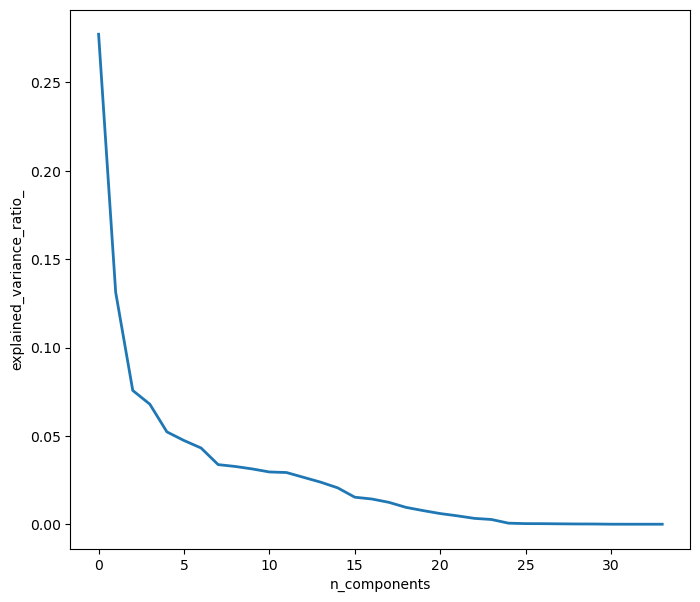

In [13]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_scaled)

plt.figure(1, figsize=(8, 7))
plt.clf()  # keeping the visualization clean
plt.plot(pca.explained_variance_ratio_, linewidth=2)

# explained_variance_ratio_ is the proportion of variance explained by each of the principal components (PCs) extracted from the data
plt.xlabel('n_components')
plt.ylabel('explained_variance_ratio_')

# performing PCA

#pca = PCA(n_components = 5)
#X_pca = pca.fit_transform(X_scaled)

# Apply PCA
pca = PCA(n_components=0.95)  # Retain 95% variance
X_pca = pca.fit_transform(X_scaled)

print(f"Number of Principal Components Selected: {pca.n_components_}")

# Explained variance ratio
explained_variance = np.cumsum(pca.explained_variance_ratio_)
print("Explained Variance Ratio:", explained_variance)

# Convert PCA transformed data back to DataFrame
df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(pca.n_components_)])

# creating features and label

X = df.drop('energy_sum', axis = 1)    # features
y = df['energy_sum']   # target

# Standardize features (PCA requires normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=0.95)  # Retain 95% variance
X_pca = pca.fit_transform(df)

# Print the number of components selected
print(f"Number of Principal Components Selected: {pca.n_components_}")

# Explained variance ratio
explained_variance = np.cumsum(pca.explained_variance_ratio_)
print("Explained Variance Ratio:", explained_variance)

# Convert PCA transformed data back to DataFrame
df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(pca.n_components_)])

# calculating explained variance
explained_variance = pca.explained_variance_ratio_
explained_variance

In [14]:
import pandas as pd

# Get the absolute values of PCA components (importance of each feature)
loading_matrix = pd.DataFrame(
    abs(pca.components_), 
    columns=df.columns  # Original feature names
)

# Display first few rows
print(loading_matrix.head()) 


   energy_median  energy_mean  energy_max  energy_std  energy_sum  energy_min  \
0       0.002363     0.003095    0.002400    0.002932    0.003095    0.000259   
1       0.406216     0.466600    0.386305    0.399450    0.466600    0.300310   
2       0.002355     0.001825    0.001069    0.000735    0.001825    0.003063   
3       0.004905     0.003569    0.000858    0.000505    0.003569    0.006728   
4       0.007379     0.002855    0.004707    0.005560    0.002855    0.012849   

   temperatureMax  windBearing  dewPoint  cloudCover  ...    cloudy       fog  \
0        0.319790     0.039978  0.291734    0.098015  ...  0.013681  0.055168   
1        0.002921     0.004436  0.000363    0.005782  ...  0.001329  0.000456   
2        0.001350     0.053750  0.220908    0.287617  ...  0.127548  0.346412   
3        0.021629     0.173492  0.011213    0.038877  ...  0.010607  0.310969   
4        0.056163     0.146983  0.007598    0.032856  ...  0.083438  0.045158   

   partly-cloudy-day  part

# 

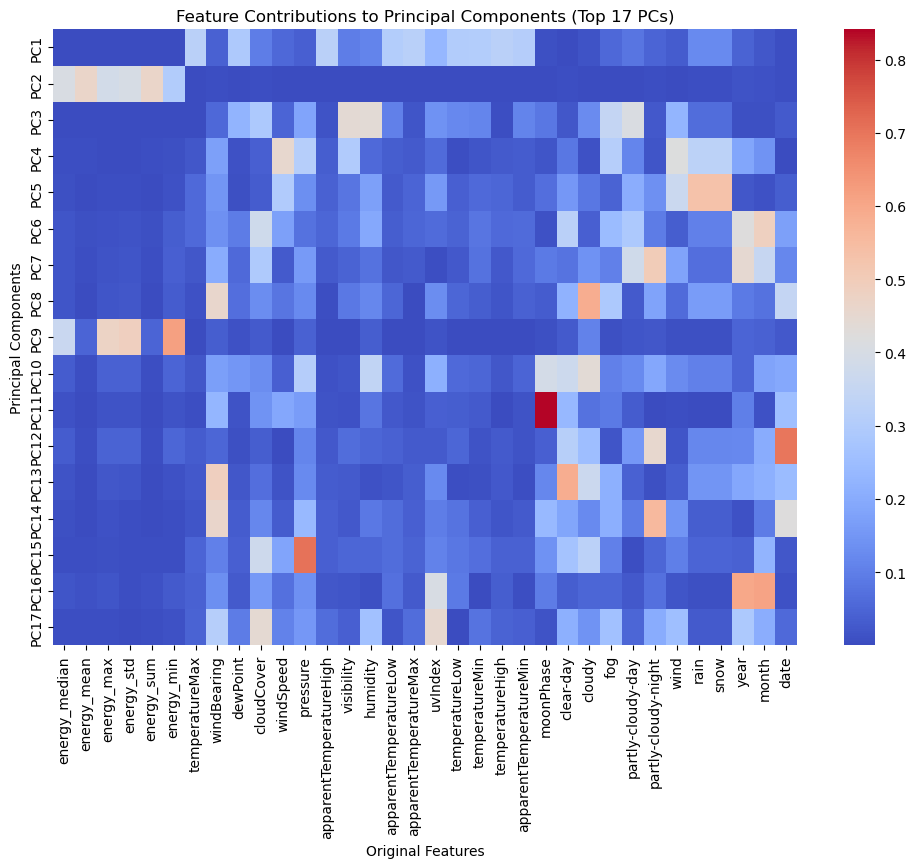

In [19]:
# Assuming `pca` is your trained PCA model and `df` is your original dataset
loading_matrix = pd.DataFrame(
    abs(pca.components_),  # Take absolute values to get the strength of influence
    columns=df.columns  # Retain original feature names
)

# Select the first 17 principal components
loading_matrix_17 = loading_matrix.iloc[:17, :]

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(loading_matrix_17, cmap="coolwarm", annot=False, xticklabels=True, yticklabels=[f"PC{i+1}" for i in range(17)])
plt.xlabel("Original Features")
plt.ylabel("Principal Components")
plt.title("Feature Contributions to Principal Components (Top 17 PCs)")
plt.xticks(rotation=90)
plt.show()


In [20]:
# Get the top contributing feature for each of the 17 PCs
top_features_per_pc = loading_matrix_17.idxmax(axis=1)

# Count how often each feature appears in the top contributing list
feature_counts = top_features_per_pc.value_counts()

# Display results
print("Top features for each PC:\n", top_features_per_pc)
print("\nFeature Importance Count:\n", feature_counts)


Top features for each PC:
 0         temperatureHigh
1              energy_sum
2              visibility
3               windSpeed
4                    rain
5                   month
6     partly-cloudy-night
7                  cloudy
8              energy_min
9                  cloudy
10              moonPhase
11                   date
12              clear-day
13    partly-cloudy-night
14               pressure
15                  month
16                uvIndex
dtype: object

Feature Importance Count:
 month                  2
partly-cloudy-night    2
cloudy                 2
temperatureHigh        1
energy_sum             1
visibility             1
windSpeed              1
rain                   1
energy_min             1
moonPhase              1
date                   1
clear-day              1
pressure               1
uvIndex                1
Name: count, dtype: int64


1. Some features appear multiple times, meaning they are influential in multiple PCs:

   -month appears twice.
        1. partly-cloudy-night appears twice.
        2. cloudy appears twice.
   
2. Unique Features Selected:
          temperatureHigh, energy_sum, visibility, windSpeed, rain, energy_min, moonPhase, date, clear-day, pressure, uvIndex appear only once.

In [24]:
# Keep only the selected important features from the original dataset
selected_features = feature_counts.index.tolist()
df_reduced = df[selected_features]
selected_features

['month',
 'partly-cloudy-night',
 'cloudy',
 'temperatureHigh',
 'energy_sum',
 'visibility',
 'windSpeed',
 'rain',
 'energy_min',
 'moonPhase',
 'date',
 'clear-day',
 'pressure',
 'uvIndex']

In [25]:
df_reduced

,month,partly-cloudy-night,cloudy,temperatureHigh,energy_sum,visibility,windSpeed,rain,energy_min,moonPhase,date,clear-day,pressure,uvIndex
day,,,,,,,,,,,,,,
2011-11-24,11,0,0,15.57,12.135,12.68,2.45,1,0.092,0.21,24,0,1009.46,1.0
2011-11-24,11,0,0,15.57,2.304,12.68,2.45,1,0.047,0.21,24,0,1009.46,1.0
2011-11-24,11,0,0,15.57,8.394,12.68,2.45,1,0.036,0.21,24,0,1009.46,1.0
2011-11-24,11,0,0,15.57,4.620,12.68,2.45,1,0.023,0.21,24,0,1009.46,1.0
2011-11-24,11,0,0,15.57,14.258,12.68,2.45,1,0.127,0.21,24,0,1009.46,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-02-27,2,0,0,9.21,0.467,9.08,1.64,1,0.000,0.01,27,0,1002.50,2.0
2014-02-27,2,0,0,9.21,7.671,9.08,1.64,1,0.025,0.01,27,0,1002.50,2.0
2014-02-27,2,0,0,9.21,10.138,9.08,1.64,1,0.023,0.01,27,0,1002.50,2.0


In [26]:
# Save the cleaned energy dataset
df_reduced.to_csv("E:/Project/Submissions/Datasets/df_reduced_pca.csv") 
print(f"\nReduced dataset saved as: df_reduced_pca.csv")


Reduced dataset saved as: df_reduced_pca.csv
